<a href="https://colab.research.google.com/github/blkmonday/AI-Phishing-Detection/blob/main/Phishing%20detection%20Part%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Model Training and Comparison

Second of two notebooks. Reads `phishing_cleaned.csv` produced by Part 1 —
[`AI_Phishing_Detection.ipynb`](AI_Phishing_Detection.ipynb) — and trains Logistic Regression,
Random Forest, and a fine-tuned BERT on an identical 80/20 split.

**Requires a GPU runtime** for the BERT section (Runtime → Change runtime type → T4 GPU).


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Phishing_Detection_Projection/phishing_cleaned.csv')
print(f"Loaded {len(df)} emails")

Mounted at /content/drive/
Loaded 39154 emails


In [ ]:
from sklearn.model_selection import train_test_split

X = df['body']
## the input( email text ) What the model reads
y = df['label']
## the answer key( 0 to 1) What the mdeol is trying to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
## splits the data into two groups 80 % training, 20 % testing to quiz the model on these to see how it performs
 ## random state is the seed number so the split is the same every time it is ran. Makes results reproducible.

print(f"Training emails: {len(X_train)}")
print(f"Testing emails: {len(X_test)}")

Training emails: 31323
Testing emails: 7831


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
## TfidfVectorier: this tool coverts words into numbers
## max_features=5000: only keeps the 5,000 most important words to limit thousands of features slowing the tool
## stop_words = 'english' = automatically removes filler words like 'the' 'and' 'is'
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
## fit_transform on training data learns which words matter and converts the text
## transform on test data - converts test text using what is already learned
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (31323, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)
## creates model
lr_model.fit(X_train_tfidf, y_train)
## .fit is where the model learns
lr_predictions = lr_model.predict(X_test_tfidf)
## .predict is where the model guesses phishing or legit
print("=== Logiistic Regression Results ===")
print(classification_report(y_test, lr_predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))
## classification_report gives precision, recall, and F1-score all at once
## Confusion matrix shows the breackdown of correct vs incorrect predictions

=== Logiistic Regression Results ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3490
           1       0.99      1.00      0.99      4341

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

Confusion Matrix:
[[3448   42]
 [  21 4320]]


Now it is time to test Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

rf_predictions = rf_model.predict(X_test_tfidf)

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3490
           1       0.99      0.99      0.99      4341

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

Confusion Matrix:
[[3463   27]
 [  25 4316]]


Both models hit 99% but random forest made slightly fewer total errors - 55 vs 63. It had fewe false positives with 31 vs 42 meaning it was a tad bit better at not flagging legit emails as phishing. But logistic regression had ferwer false negatives 21 vs 24 meaning it caught slightly more actual phishing

Time for BERt which will be a bit different turning words into numbers as it has its own way of understanding text. It also needs a GPU to train in a reasonable time

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader , Dataset
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("BERT tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokenizer loaded!


In [ ]:
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = EmailDataset(X_train, y_train, tokenizer)
test_dataset = EmailDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

Training batches: 1958
Testing batches: 490


In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.cuda()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("BERT model loaded and ready!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded and ready!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_num, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()
        labels = batch['label'].cuda()

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        if batch_num % 200 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_num}/{len(train_loader)} | Loss: {loss.item():.4f}")

    accuracy = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Complete | Avg Loss: {avg_loss:.4f} | Training Accuracy: {accuracy:.4f}")
    print("---")

print("Training complete!")

Epoch 1/3 | Batch 0/1958 | Loss: 0.7040
Epoch 1/3 | Batch 200/1958 | Loss: 0.0045
Epoch 1/3 | Batch 400/1958 | Loss: 0.0032
Epoch 1/3 | Batch 600/1958 | Loss: 0.0011
Epoch 1/3 | Batch 800/1958 | Loss: 0.0008
Epoch 1/3 | Batch 1000/1958 | Loss: 0.0013
Epoch 1/3 | Batch 1200/1958 | Loss: 0.0013


In [ ]:
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()
        labels = batch['label'].cuda()

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=== BERT RESULTS ===")
print(classification_report(all_labels, all_predictions))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Random Forest', 'BERT']

precision = [0.99, 0.99, 1.00]
recall = [1.00, 0.99, 0.99]
f1 = [0.99, 0.99, 0.99]
total_errors = [63, 55, 50]
false_positives = [42, 31, 11]
false_negatives = [21, 24, 39]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Precision, Recall, F1 comparison
x = np.arange(len(models))
width = 0.25
axes[0,0].bar(x - width, precision, width, label='Precision', color='#2ecc71')
axes[0,0].bar(x, recall, width, label='Recall', color='#3498db')
axes[0,0].bar(x + width, f1, width, label='F1-Score', color='#e74c3c')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Model Performance Comparison')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].legend()
axes[0,0].set_ylim(0.97, 1.01)

# Chart 2: Total Errors
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0,1].bar(models, total_errors, color=colors, edgecolor='black')
axes[0,1].set_title('Total Misclassifications')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(total_errors):
    axes[0,1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Chart 3: False Positives vs False Negatives
axes[1,0].bar(x - 0.15, false_positives, 0.3, label='False Positives', color='#e74c3c')
axes[1,0].bar(x + 0.15, false_negatives, 0.3, label='False Negatives', color='#f39c12')
axes[1,0].set_title('Error Type Breakdown')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models)
axes[1,0].legend()
for i, v in enumerate(false_positives):
    axes[1,0].text(i - 0.15, v + 1, str(v), ha='center', fontsize=9)
for i, v in enumerate(false_negatives):
    axes[1,0].text(i + 0.15, v + 1, str(v), ha='center', fontsize=9)

# Chart 4: Training Time
training_times = [5, 120, 1800]
axes[1,1].bar(models, training_times, color=colors, edgecolor='black')
axes[1,1].set_title('Training Time (seconds)')
axes[1,1].set_ylabel('Seconds')
axes[1,1].set_yscale('log')
for i, v in enumerate(training_times):
    label = f"{v}s" if v < 60 else f"{v//60}min"
    axes[1,1].text(i, v * 1.3, label, ha='center', fontweight='bold')

plt.suptitle('Phishing Email Detection: Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Phishing_Detection_Projection/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive!")


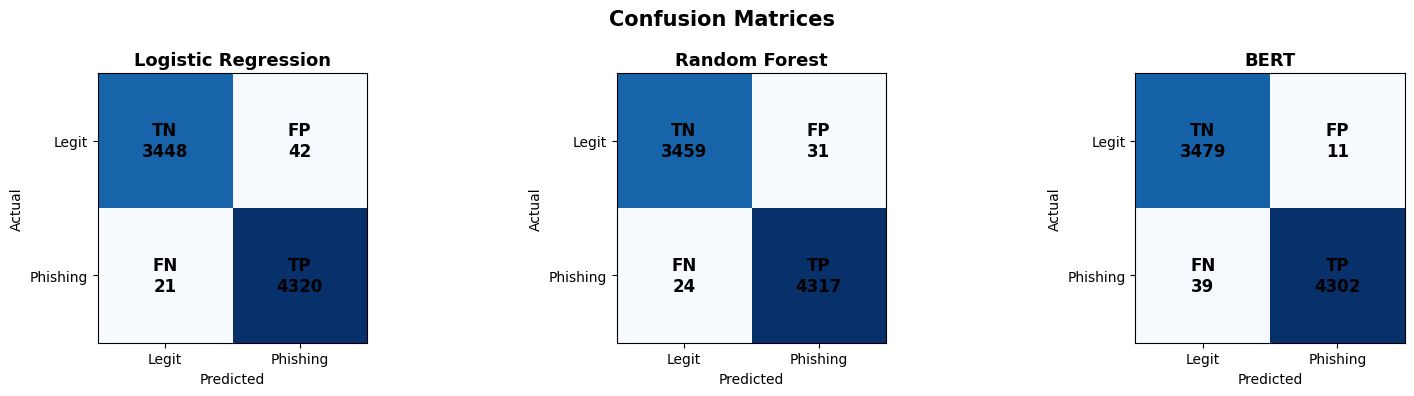

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cms = [
    [[3448, 42], [21, 4320]],
    [[3459, 31], [24, 4317]],
    [[3479, 11], [39, 4302]]
]

labels = [['TN', 'FP'], ['FN', 'TP']]

for i, (cm, title) in enumerate(zip(cms, models)):
    im = axes[i].imshow(cm, cmap='Blues')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Legit', 'Phishing'])
    axes[i].set_yticklabels(['Legit', 'Phishing'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    for row in range(2):
        for col in range(2):
            axes[i].text(col, row, f"{labels[row][col]}\n{cm[row][col]}",
                        ha='center', va='center', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Phishing_Detection_Projection/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")